
Procesando dataset: orig
  Componentes seleccionados: 17
  Varianza explicada total: 95.07%


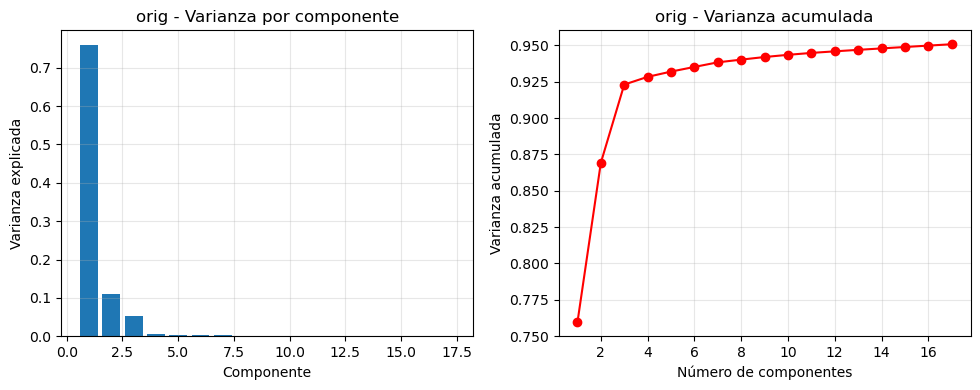

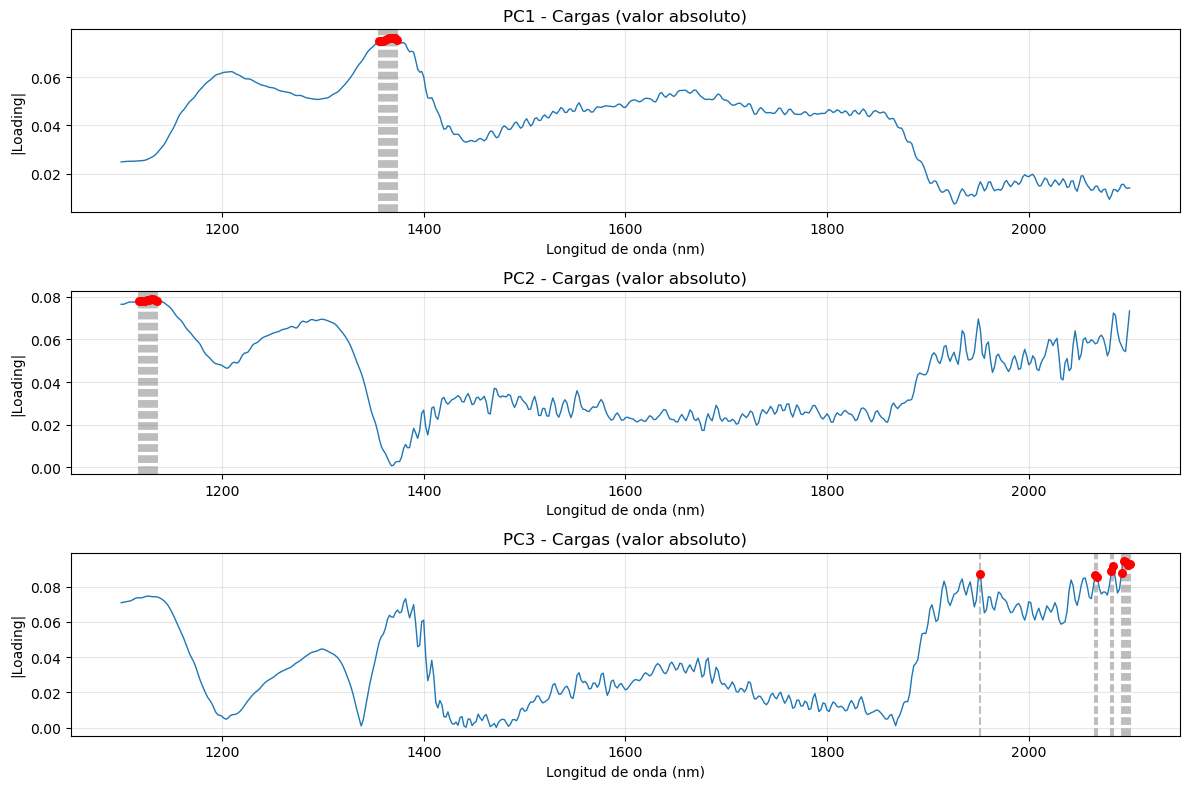

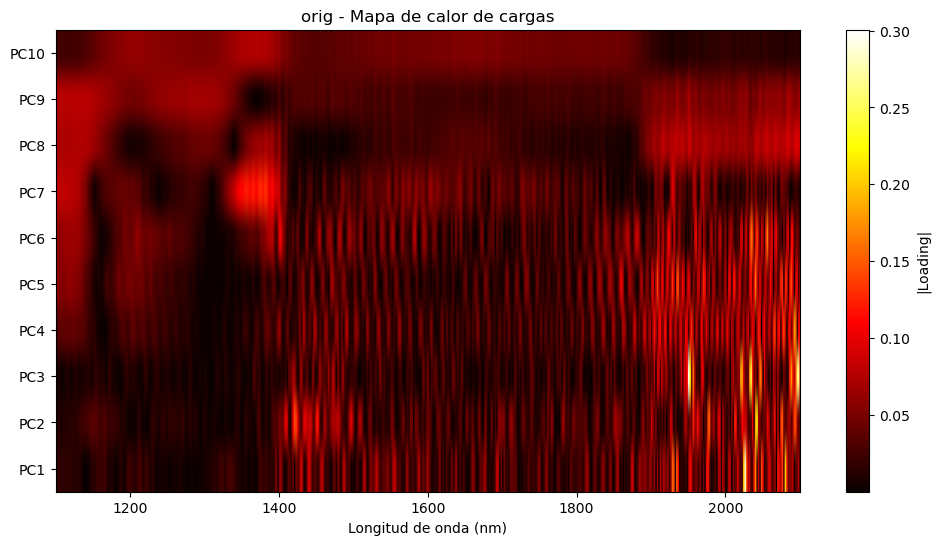


Procesando dataset: sg
  Componentes seleccionados: 3
  Varianza explicada total: 96.56%


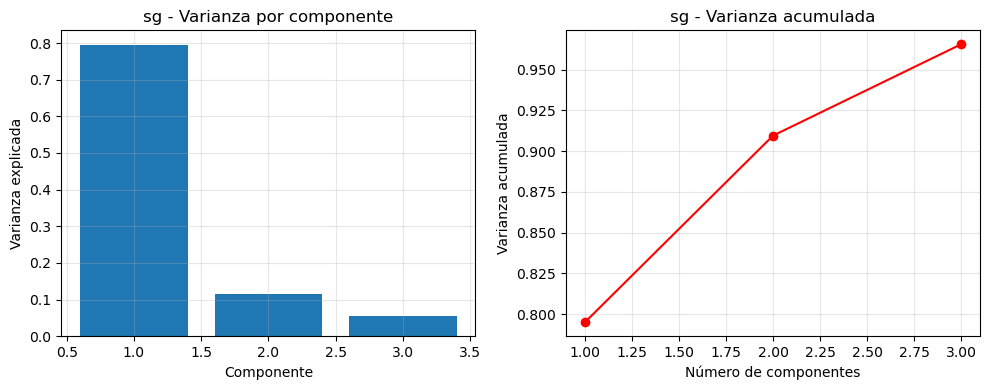

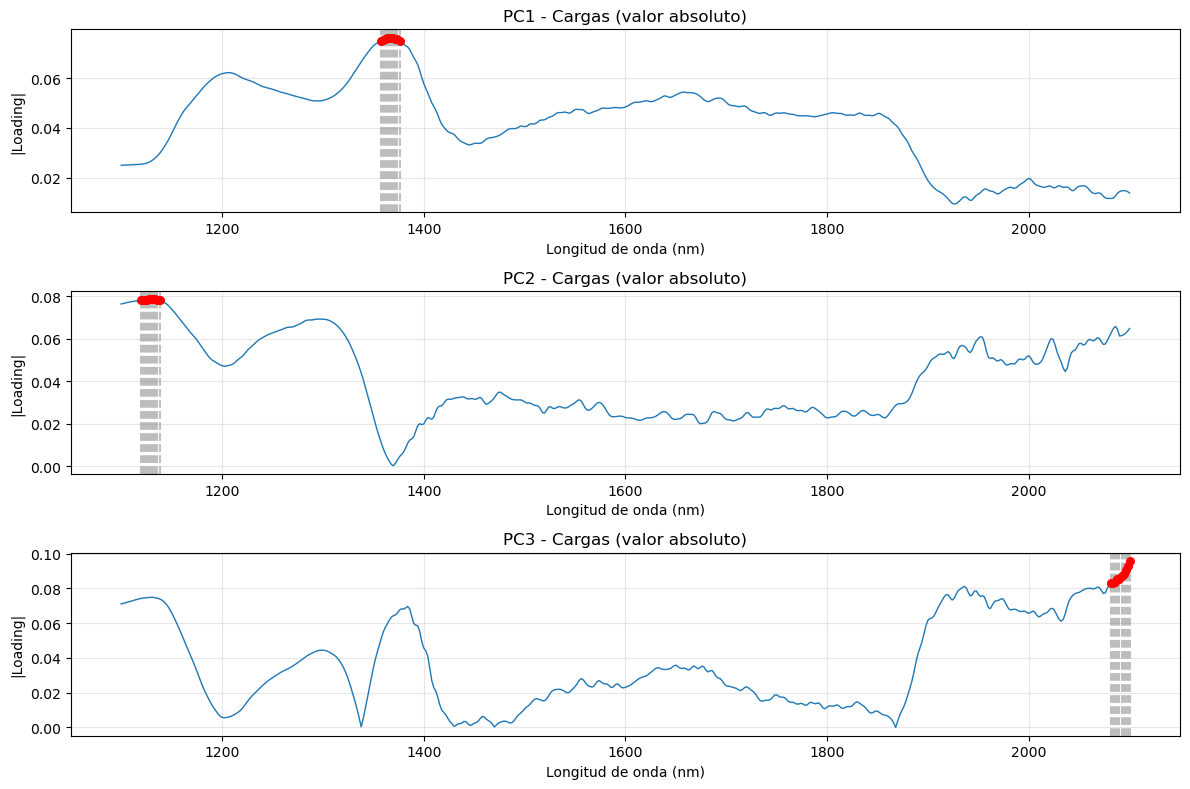

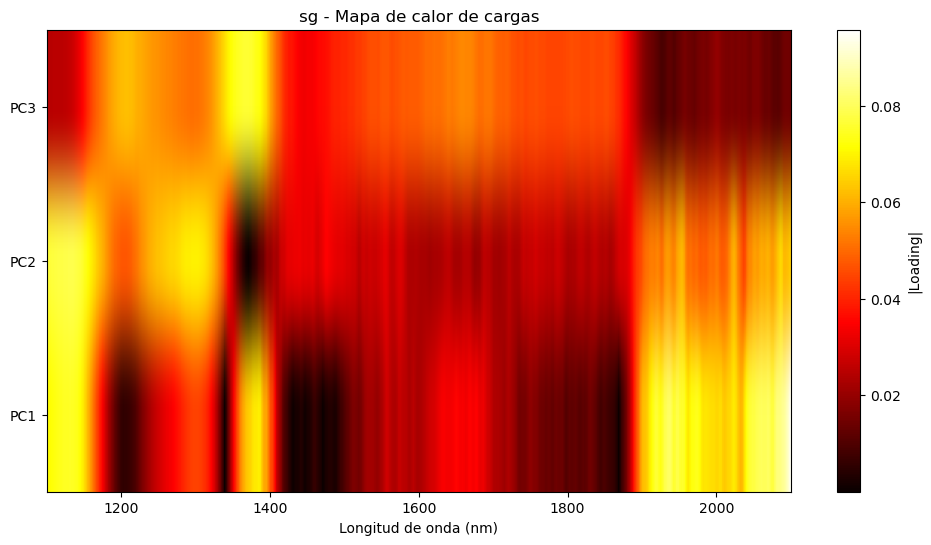


Procesando dataset: msc
  Componentes seleccionados: 101
  Varianza explicada total: 95.02%


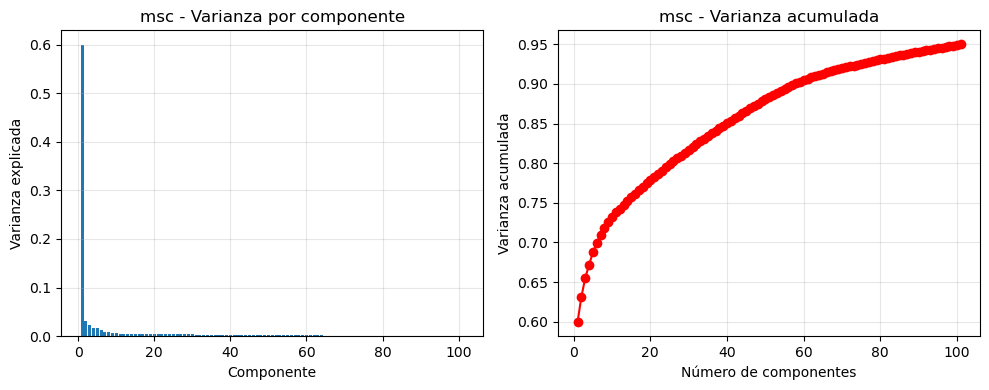

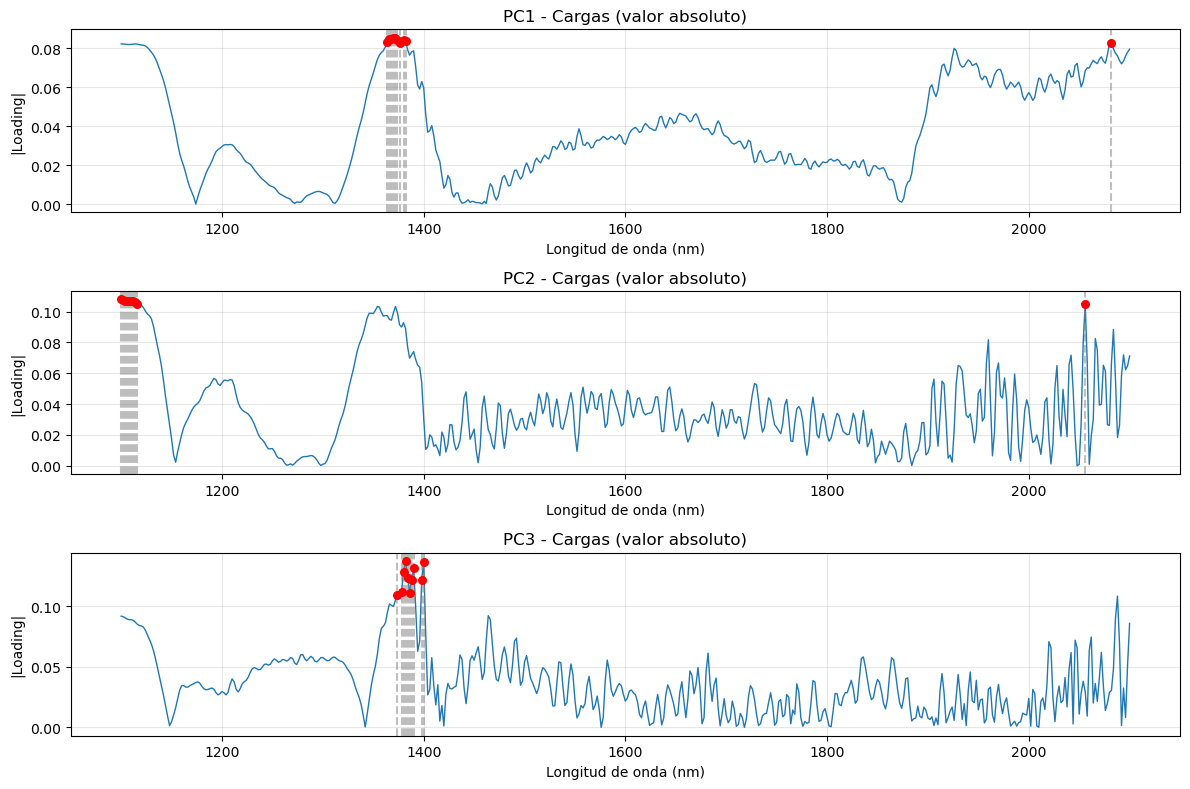

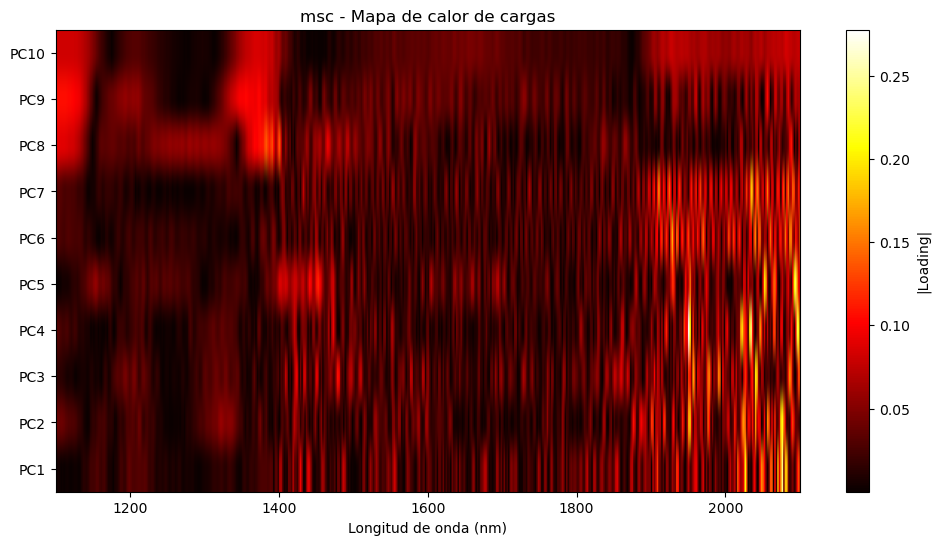


Procesando dataset: snv
  Componentes seleccionados: 102
  Varianza explicada total: 95.01%


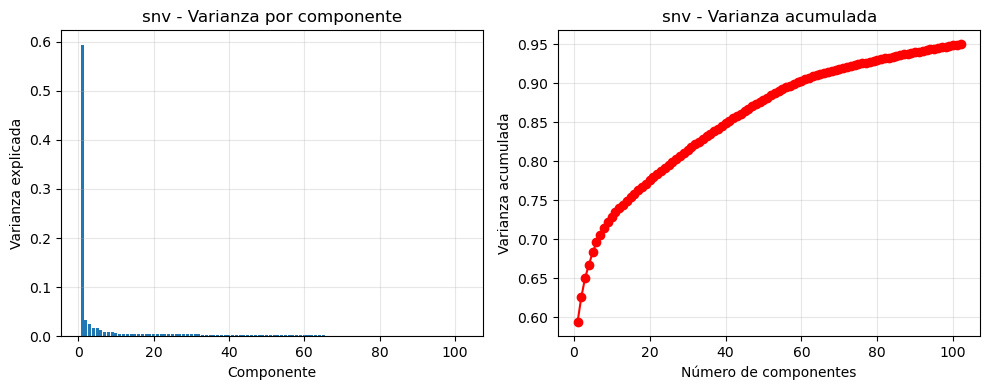

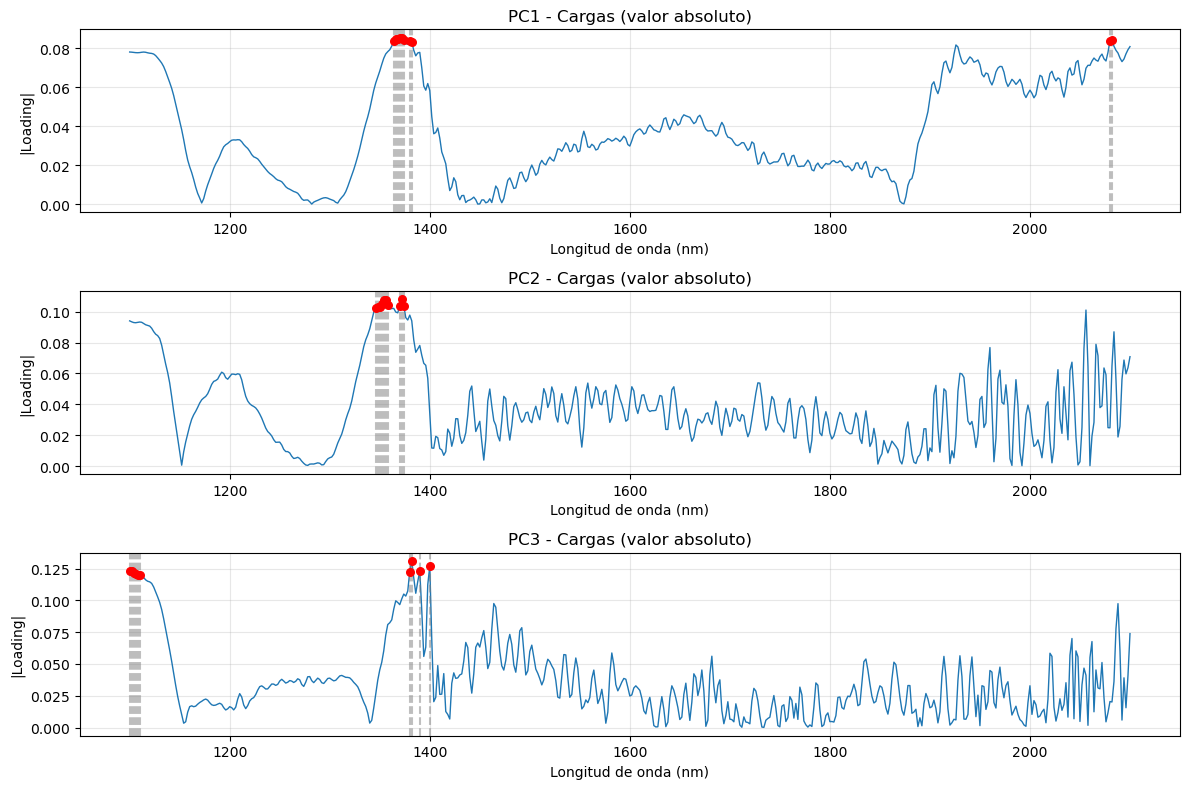

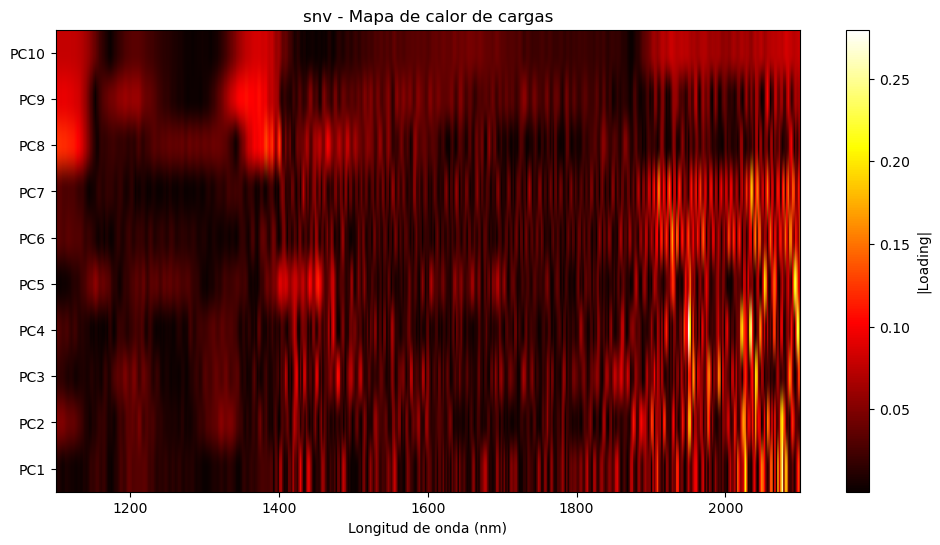


✅ Datos con PCA guardados en: split_data_dict_pca.pkl
   Gráficos en: pca_analysis/


In [1]:
# apply_pca_and_analyze.py
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# ============================================
# CONFIGURACIÓN
# ============================================
VARIANZA_OBJETIVO = 0.95  # % de varianza a retener
RUTA_SPLIT = "split_data_dict.pkl"
RUTA_SALIDA = "split_data_dict_pca.pkl"
DIR_GRAFICOS = "pca_analysis"
os.makedirs(DIR_GRAFICOS, exist_ok=True)

# Cargar split original
with open(RUTA_SPLIT, "rb") as f:
    obj = pickle.load(f)
    split_data_dict = obj["split"]
    TEST_SIZE = obj["prueba"]

# Diccionarios para los nuevos splits y para guardar info
split_data_dict_pca = {}
pca_info = {}

# Para almacenar longitudes de onda (suponiendo rango 1100-2100 nm con 501 puntos)
wavelengths = np.linspace(1100, 2100, 501)  # ajusta si es necesario

for dataset, data in split_data_dict.items():
    print("\n" + "="*50)
    print(f"Procesando dataset: {dataset}")
    print("="*50)

    X_train = data["train"]["X"]
    y_train = data["train"]["Y"]  # no se usa para PCA
    X_test = data["test"]["X"]
    y_test = data["test"]["Y"]

    # Centrar los datos (PCA requiere centrado, no escalado porque ya están preprocesados)
    # Usamos StandardScaler con with_std=False para solo centrar
    scaler_centrado = StandardScaler(with_std=False)
    X_train_c = scaler_centrado.fit_transform(X_train)
    X_test_c = scaler_centrado.transform(X_test)

    # Aplicar PCA
    pca = PCA(n_components=VARIANZA_OBJETIVO)
    X_train_pca = pca.fit_transform(X_train_c)
    X_test_pca = pca.transform(X_test_c)

    n_comp = X_train_pca.shape[1]
    varianza_acum = np.sum(pca.explained_variance_ratio_)

    print(f"  Componentes seleccionados: {n_comp}")
    print(f"  Varianza explicada total: {varianza_acum:.2%}")

    # Guardar en nuevo split
    split_data_dict_pca[dataset] = {
        "train": {"X": X_train_pca, "Y": y_train},
        "test": {"X": X_test_pca, "Y": y_test}
    }

    # Guardar info para análisis posterior
    pca_info[dataset] = {
        "n_components": n_comp,
        "explained_variance_ratio": pca.explained_variance_ratio_.tolist(),
        "cumulative_variance": np.cumsum(pca.explained_variance_ratio_).tolist(),
        "components": pca.components_,  # shape (n_comp, n_features)
        "mean": scaler_centrado.mean_.tolist(),
        "wavelengths": wavelengths.tolist()
    }

    # ---------------------------
    # Gráficos
    # ---------------------------
    # 1. Varianza explicada
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.bar(range(1, n_comp+1), pca.explained_variance_ratio_[:n_comp])
    plt.xlabel('Componente')
    plt.ylabel('Varianza explicada')
    plt.title(f'{dataset} - Varianza por componente')
    plt.grid(True, alpha=0.3)

    plt.subplot(1,2,2)
    plt.plot(range(1, n_comp+1), np.cumsum(pca.explained_variance_ratio_[:n_comp]), 'ro-')
    plt.xlabel('Número de componentes')
    plt.ylabel('Varianza acumulada')
    plt.title(f'{dataset} - Varianza acumulada')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{DIR_GRAFICOS}/{dataset}_variance.png", dpi=150)
    plt.show()

    # 2. Cargas (loadings) de los primeros 3 componentes
    # Mostramos el valor absoluto para ver contribuciones
    fig, axes = plt.subplots(3, 1, figsize=(12, 8))
    for i in range(min(3, n_comp)):
        ax = axes[i]
        ax.plot(wavelengths, np.abs(pca.components_[i]), linewidth=1)
        ax.set_title(f'PC{i+1} - Cargas (valor absoluto)')
        ax.set_xlabel('Longitud de onda (nm)')
        ax.set_ylabel('|Loading|')
        ax.grid(True, alpha=0.3)
        # Marcar los 10 picos más altos
        top_indices = np.argsort(np.abs(pca.components_[i]))[-10:]
        top_wl = wavelengths[top_indices]
        ax.scatter(top_wl, np.abs(pca.components_[i][top_indices]), color='red', s=30, zorder=5)
        for wl in top_wl:
            ax.axvline(wl, color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{DIR_GRAFICOS}/{dataset}_loadings.png", dpi=150)
    plt.show()


# Guardar todo
with open(RUTA_SALIDA, "wb") as f:
    pickle.dump({
        "split": split_data_dict_pca,
        "prueba": TEST_SIZE,
        "pca_info": pca_info
    }, f)

print(f"\n✅ Datos con PCA guardados en: {RUTA_SALIDA}")
print(f"   Gráficos en: {DIR_GRAFICOS}/")

# También guardar un resumen de longitudes de onda relevantes en un archivo de texto
with open(f"{DIR_GRAFICOS}/top_wavelengths.txt", "w") as f:
    f.write("Resumen de longitudes de onda más influyentes (top 10 por PC)\n")
    f.write("="*60 + "\n")
    for dataset, info in pca_info.items():
        f.write(f"\nDataset: {dataset}\n")
        comps = np.array(info["components"])
        for i in range(min(3, comps.shape[0])):
            loadings = np.abs(comps[i])
            top_idx = np.argsort(loadings)[-10:]
            top_wl = wavelengths[top_idx]
            f.write(f"  PC{i+1}: {np.sort(top_wl).round(1).tolist()}\n")
        f.write("\n")

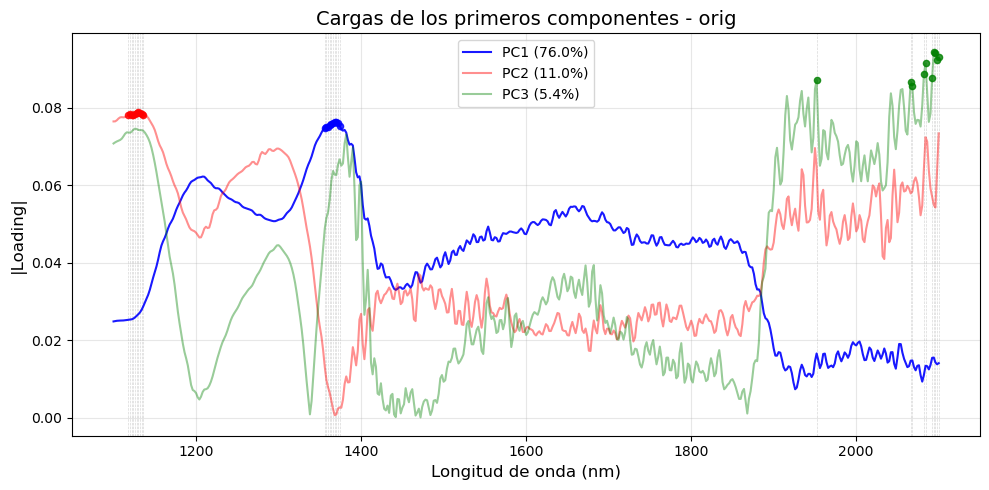

Gráfico guardado: pca_analysis\orig_loadings_combined_marked.png


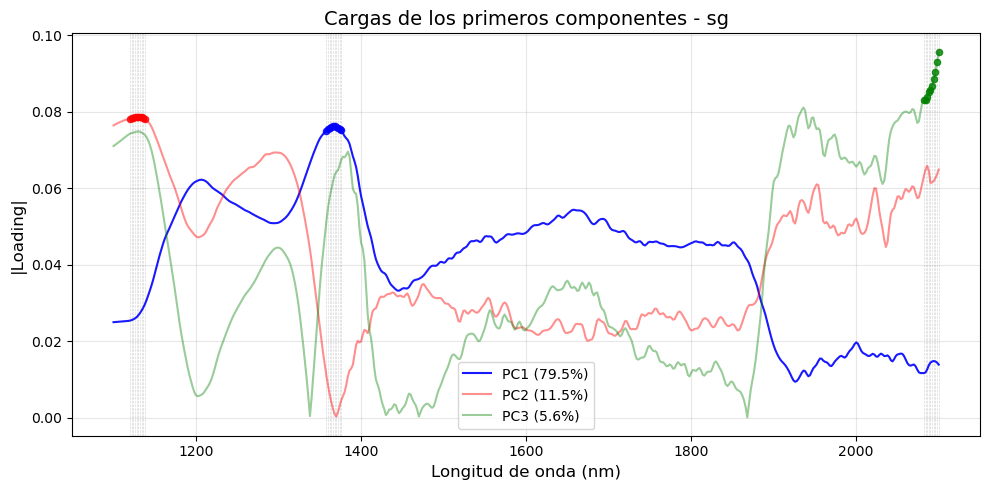

Gráfico guardado: pca_analysis\sg_loadings_combined_marked.png


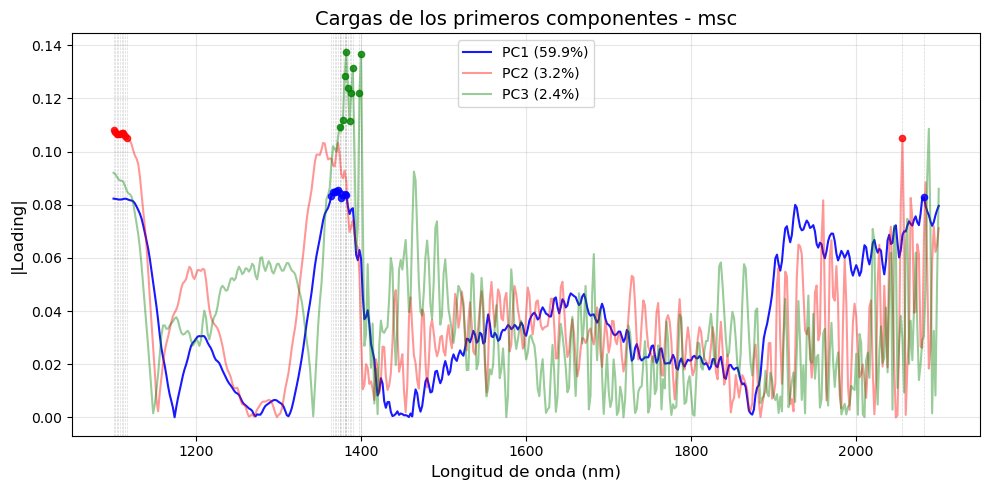

Gráfico guardado: pca_analysis\msc_loadings_combined_marked.png


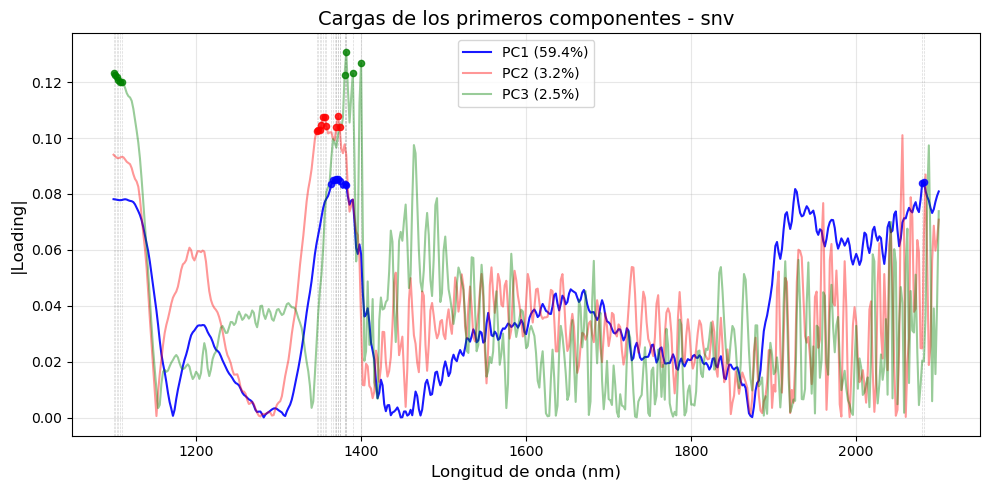

Gráfico guardado: pca_analysis\snv_loadings_combined_marked.png


In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuración
ARCHIVO_PCA = "split_data_dict_pca.pkl"
DIR_GRAFICOS = "pca_analysis"
os.makedirs(DIR_GRAFICOS, exist_ok=True)

# Cargar la información del PCA
with open(ARCHIVO_PCA, "rb") as f:
    data = pickle.load(f)
    pca_info = data["pca_info"]

# Colores para los componentes
colores = ['blue', 'red', 'green']
etiquetas = ['PC1', 'PC2', 'PC3']

# Procesar cada dataset
for dataset, info in pca_info.items():
    wavelengths = np.array(info["wavelengths"])
    components = np.array(info["components"])  # shape (n_componentes, n_features)
    var_ratios = info["explained_variance_ratio"]  # lista con varianza de cada componente
    
    # Tomar solo los primeros 3 componentes (si hay menos, se ajusta)
    n_comp = min(3, components.shape[0])
    
    plt.figure(figsize=(10, 5))
    
    # Primero dibujamos las líneas verticales de los picos para todos los componentes
    # (las hacemos al fondo)
    for i in range(n_comp):
        loading_abs = np.abs(components[i])
        top_indices = np.argsort(loading_abs)[-10:]
        for idx in top_indices:
            plt.axvline(wavelengths[idx], color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
    
    # Luego dibujamos las líneas de los componentes con transparencia proporcional a la varianza
    # Normalizamos la transparencia: el de mayor varianza tendrá alpha=0.9, el menor alpha=0.4 (por ejemplo)
    # para que todos se vean, pero con diferencia.
    max_var = max(var_ratios[:n_comp])
    min_var = min(var_ratios[:n_comp])
    
    for i in range(n_comp):
        loading_abs = np.abs(components[i])
        # Ajustar alpha: entre 0.4 y 0.9 según la varianza relativa
        if max_var > min_var:
            alpha = 0.4 + 0.5 * (var_ratios[i] - min_var) / (max_var - min_var)
        else:
            alpha = 0.7  # si todas iguales
        # Etiqueta con varianza explicada
        label = f'{etiquetas[i]} ({var_ratios[i]*100:.1f}%)'
        plt.plot(wavelengths, loading_abs, color=colores[i], linewidth=1.5, alpha=alpha, label=label)
        
        # Marcar los 10 picos más altos de este componente con puntos
        top_indices = np.argsort(loading_abs)[-10:]
        top_wl = wavelengths[top_indices]
        top_vals = loading_abs[top_indices]
        plt.scatter(top_wl, top_vals, color=colores[i], s=20, zorder=5, alpha=0.8)
    
    plt.xlabel('Longitud de onda (nm)', fontsize=12)
    plt.ylabel('|Loading|', fontsize=12)
    plt.title(f'Cargas de los primeros componentes - {dataset}', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # Guardar
    archivo_salida = os.path.join(DIR_GRAFICOS, f"{dataset}_loadings_combined_marked.png")
    plt.savefig(archivo_salida, dpi=150)
    plt.show()
    print(f"Gráfico guardado: {archivo_salida}")